<a href="https://colab.research.google.com/github/Carereen/image-processing/blob/main/Assignment4_sec2_6853800122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt
import sys
from math import exp, sqrt

In [ ]:
def distance(point1, point2):
  return sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2)

# Low pass Filter
def idealFilterLP(D0, imgShape):
  base = np.zeros(imgShape[:2])
  rows, cols = imgShape[:2]
  center = (rows / 2, cols / 2)
  for x in range(cols):
    for y in range(rows):
      if distance((y, x), center) < D0:
        base[y, x] = 1
  return base

# High Pass
def idealFilterHP(D0, imgShape):
  base = np.ones(imgShape[:2])
  rows, cols = imgShape[:2]
  center = (rows / 2, cols / 2)
  for x in range(cols):
    for y in range(rows):
      if distance((y, x), center) < D0:
        base[y, x] = 0

  return base

In [ ]:
# Butterworth Filter
def distance(point1, point2):
  return sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2)

def butterworthLP(D0, imgShape, n):
  base = np.zeros(imgShape[:2])
  rows, cols = imgShape[:2]
  center = (rows / 2, cols / 2)
  for x in range(cols):
    for y in range(rows):
      base[y, x] = 1 / (1 + (distance((y, x), center)/ D0) ** (2 * n))
  return base

def butterworthHP(D0, imgShape, n):
  base = np.zeros(imgShape[:2])
  rows, cols = imgShape[:2]
  center = [rows / 2, cols / 2]
  for x in range(cols):
    for y in range(rows):
      base[y, x] = 1 - 1 / (1 + (distance((y, x), center) / D0) ** (2 * n))
  return base

In [ ]:
# Gaussian Filter
def distance(point1, point2):
  return sqrt((point1[0] - point2[0]) ** 2 + (point1[0] - point2[1]) ** 2)

def gaussianLP(D0, imgShape):
  base = np.zeros(imgShape[:2])
  rows, cols = imgShape[:2]
  center = (rows / 2, cols / 2)
  for x in range(cols):
    for y in range(rows):
      base[y, x] = exp(((-distance((y, x), center) ** 2) / (2 * (D0 ** 2))))
  return base

def gaussianHP(D0, imgShape):
  base = np.zeros(imgShape[:2])
  rows, cols = imgShape[:2]
  center = (rows / 2, cols / 2)
  for x in range(cols):
    for y in range(rows):
      base[y, x] = 1 - exp(((-distance((y, x), center) ** 2) / (2 * (D0 ** 2))))
  return base

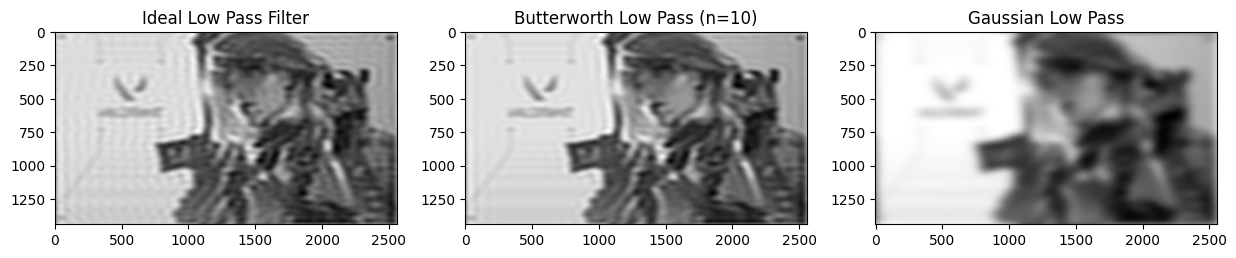

In [ ]:
# task 1
path = '/content/drive/My Drive/2568-term2/image/week4/'
image_name = 'VALORANT.jpg'
image_bgr = cv2.imread(path + image_name)

if image_bgr is None:
  print(f"Image file not found. Please check the path:{path + image_name} .")
  sys.exit()

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
filter_size = 30

plt.figure(figsize = (15, 10), constrained_layout = False)

original = np.fft.fft2(image_gray)
center = np.fft.fftshift(original)

# Ideal Low Pass Filter
idealLowPass = idealFilterLP(filter_size, image_gray.shape)
idealLowPassCenter = center * idealFilterLP(filter_size, image_gray.shape)
idealLowPass = np.fft.ifftshift(idealLowPassCenter)
inverse_idealLowPass = np.fft.ifft2(idealLowPass)

#  Butterworth Low Pass Filter
D0 = 30
n = 10

butterworthLowPassCenter = center * butterworthLP(D0, image_gray.shape, n)
butterworthLowPass = np.fft.ifftshift(butterworthLowPassCenter)
inverse_butterLowPass = np.fft.ifft2(butterworthLowPass)

# Gaussian Low Pass Filter
D0 = 10
gaussianLowPassCenter = center * gaussianLP(D0, image_gray.shape)
gaussianLowPass = np.fft.ifftshift(gaussianLowPassCenter)
inverse_gaussianLowPass = np.fft.ifft2(gaussianLowPass)


plt.subplot(231), plt.imshow(np.abs(inverse_idealLowPass), "gray"), plt.title("Ideal Low Pass Filter")
plt.subplot(232), plt.imshow(np.abs(inverse_butterLowPass), "gray"), plt.title("Butterworth Low Pass (n=" +str(n)+")")
plt.subplot(233), plt.imshow(np.abs(inverse_gaussianLowPass), "gray"), plt.title("Gaussian Low Pass")

plt.show()

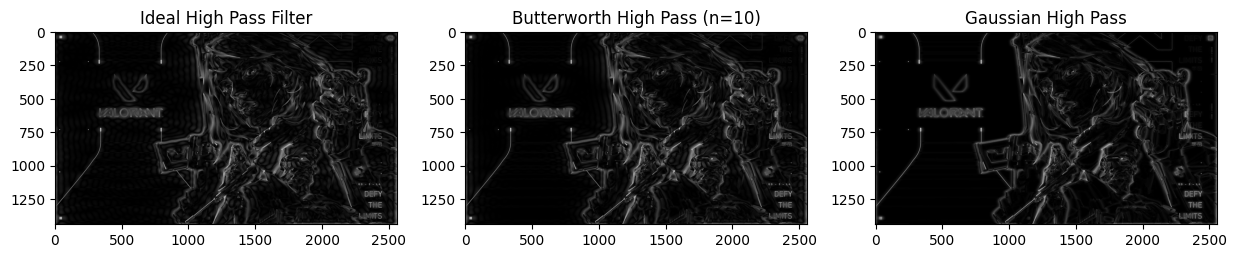

In [ ]:
# task 2
path = '/content/drive/My Drive/2568-term2/image/week4/'
image_name = 'VALORANT.jpg'
image_bgr = cv2.imread(path + image_name)

if image_bgr is None:
  print(f"Image file not found. Please check the path:{path + image_name} .")
  sys.exit()

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
filter_size = 30

plt.figure(figsize = (15, 10), constrained_layout = False)

original = np.fft.fft2(image_gray)
center = np.fft.fftshift(original)

# Ideal High Pass Filter
IdealHighPass = idealFilterHP(filter_size, image_gray.shape)
IdealHighPassCenter = center * idealFilterHP(filter_size, image_gray.shape)
IdealHighPass = np.fft.ifftshift(IdealHighPassCenter)
inverse_IdealHighPass = np.fft.ifft2(IdealHighPass)

#  Butterworth High Pass Filter
D0 = 30
n = 10

butterworthHighPassCenter = center * butterworthHP(D0, image_gray.shape, n)
butterworthHighPass = np.fft.ifftshift(butterworthHighPassCenter)
inverse_butterworthHighPass = np.fft.ifft2(butterworthHighPass)

# Gaussian High Pass Filter
D0 = 30
gaussianHighPassCenter = center * gaussianHP(D0, image_gray.shape)
gaussianHighPass = np.fft.ifftshift(gaussianHighPassCenter)
inverse_gaussianhighPass = np.fft.ifft2(gaussianHighPass)

plt.subplot(231), plt.imshow(np.abs(inverse_IdealHighPass), "gray"), plt.title("Ideal High Pass Filter")
plt.subplot(232), plt.imshow(np.abs(inverse_butterworthHighPass), "gray"), plt.title("Butterworth High Pass (n=" +str(n)+")")
plt.subplot(233), plt.imshow(np.abs(inverse_gaussianhighPass), "gray"), plt.title("Gaussian High Pass")

plt.show()

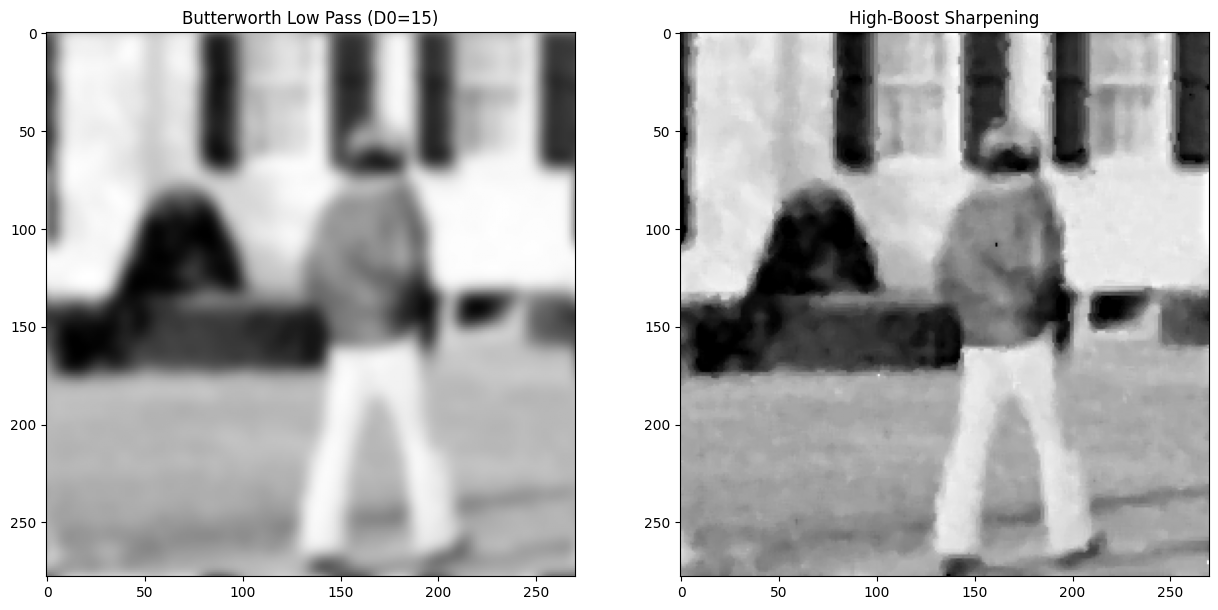

In [ ]:
# task 3
path = '/content/drive/My Drive/2568-term2/image/week4/'
image_name = 'noise.jpg'
image_bgr = cv2.imread(path + image_name)

if image_bgr is None:
  print(f"Image file not found. Please check the path:{path + image_name} .")
  sys.exit()

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

image_gray = cv2.medianBlur(image_gray, 5)

D0 = 15
original = np.fft.fft2(image_gray)
center = np.fft.fftshift(original)

plt.figure(figsize = (15, 10), constrained_layout = False)

LowPassCenter = center * gaussianLP(D0, image_gray.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)

LP = np.abs(inverse_LowPass)

image_f = image_gray.astype(np.float32)
LP = LP.astype(np.float32)

HP = image_f - LP
k = 0.5

sharpen = image_f + k * HP
sharpen = np.clip(sharpen, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Butterworth Low Pass (D0="+ str(D0)+ ")")
plt.subplot(122), plt.imshow(sharpen, cmap='gray'), plt.title("High-Boost Sharpening")

plt.show()